<a href="https://colab.research.google.com/github/Danilesmes/Connectatel-customer-analysis/blob/main/connectatel_customer_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
(users.isna().sum())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

In [ ]:
# cantidad de nulos para usage
(usage.isna().sum())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

📒 **Diagnóstico de valores nulos**

**users:**
- `city` (469 nulos, 11.7%): se recomienda investigar para imputar, ya que puede ser útil para segmentación geográfica.
- `churn_date` (3,534 nulos, 88.4%): los nulos no representan datos malos sino clientes activos — se recomienda convertir a variable binaria (1 = canceló, 0 = activo) en lugar de eliminar.

**usage:**
- `date` (50 nulos, 0.1%): se recomienda eliminar esas filas ya que son insignificantes y imputar fechas no sería realista.
- `duration` (22,076 nulos, 55.2%): se recomienda investigar por tipo de registro (`type`), ya que los nulos probablemente corresponden a mensajes donde la duración no aplica.
- `length` (17,896 nulos, 44.7%): mismo caso que `duration` — los nulos probablemente corresponden a llamadas donde el largo de mensaje no aplica. Se recomienda investigar por `type` antes de tomar una decisión.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
(users[['user_id', 'age']].describe())

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


## Resumen estadístico
- La columna `user_id`: identificador único, no se analiza estadísticamente.
- La columna `age`: contiene sentinel values identificados por el valor mínimo de -999 (valor imposible para una edad real). El std de 123 confirma que estos valores están distorsionando la distribución — deben reemplazarse por NaN antes de analizar.


In [ ]:
# explorar columnas numéricas de usage
(usage[['id','user_id', 'duration','length']].describe())

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


## Resumen estadístico
- Las columnas `id` y `user_id`: identificadores únicos, no se analizan estadísticamente.
- La columna `duration`: distribución con poca variación (std=6.8), pero el máximo de 120 sugiere la presencia de outliers hacia la derecha que deben investigarse.
- La columna `length`: mayor variación que duration (std=56 > mean=52) y un máximo de 1,490 muy alejado del percentil 75 (64), indicando outliers más extremos hacia la derecha.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

users[columnas_user].describe()


,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


## Resumen categórico
**users:**
- `city`: 3,531 valores no nulos de 4,000 (469 faltantes).
  Tiene 7 ciudades únicas siendo Bogotá la más frecuente con 808 registros.
- `plan`: sin valores faltantes, solo 2 categorías disponibles.
  El plan Básico es el más común con 2,595 clientes (64.9% del total).

In [ ]:
# explorar columna categórica de usage

(usage['type'].describe())

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

## Resumen categórico

**usage:**

- `type`: sin valores faltantes, 2 categorías — `text` es la más frecuente
con 22,092 registros (55.2%) y `call` con los 17,908 restantes (44.8%). Esto sugiere que `duration` aplica a llamadas y `length` a mensajes, sin embargo existe una discrepancia de 12 registros entre el total de `text` (22,092) y los valores no nulos de `length` (22,104), lo que indica posibles registros mal clasificados que deberán investigarse en la limpieza.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

## Diagnóstico de valores inválidos o sentinels

- `age`: contiene sentinel values representados por -999 (valor imposible para
  una edad real). Acción: reemplazar por NaN y recalcular estadísticas.

- `duration` y `length`: ambas presentan distribución sesgada a la derecha
  (right skewed) con outliers extremos. Acción: investigar y aplicar winsorización
  o capping para moderar el impacto de los valores extremos en el análisis.

- `city`: 469 valores faltantes (11.7%). No se recomienda eliminar las filas ya
  que el resto de la información del cliente sigue siendo útil para otros análisis.
  Si se realiza un análisis geográfico, estas filas se ignorarían.

- `type`: se detectó una discrepancia de 12 registros entre el total de `text`
  (22,092) y los valores no nulos de `length` (22,104), sugiriendo posibles
  registros mal clasificados. Acción: investigar si `duration` y `length`
  corresponden correctamente a `call` y `text` respectivamente.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'],errors='coerce')

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'],errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users
(users['reg_date'].dt.year.value_counts().sort_index())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

**`reg_date` (users):**
- La mayoría de registros están entre 2022-2024 (distribución uniforme ~1,314-1,330
  por año). Sin embargo, se detectaron 40 registros con año 2026, que está fuera
  del rango válido del análisis (hasta 2024).

In [ ]:
# Revisar los años presentes en `date` de usage
(usage['date'].dt.year.value_counts().sort_index())

2024.0    39950
Name: date, dtype: int64

**`date` (usage):**
- Toda la data corresponde al año 2024 (39,950 registros), con 50 valores nulos que se asumen del mismo año pero sin fecha exacta conocida.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

**`reg_date` (users):**
- La mayoría de registros están entre 2022-2024 (distribución uniforme ~1,314-1,330 por año). Sin embargo, se detectaron 40 registros con año 2026, que está fuera  del rango válido del análisis (hasta 2024).
- Acción: evaluar si son errores de captura corregibles. De no ser posible
  identificar la fecha correcta, se recomienda eliminar estos registros ya que
  no pertenecen al período de análisis.

  **`date` (usage):**
- Toda la data corresponde al año 2024 (39,950 registros), con 50 valores nulos que se asumen del mismo año pero sin fecha exacta conocida.
- Acción: los 50 nulos pueden mantenerse para análisis de uso general ya que el año es consistente, pero se excluirán de análisis que requieran fecha exacta.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999,age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].isna().sum()

565

In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts().sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean()*100)

type
call     0.000000
text    99.927576
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().mean()*100)

type
call    99.932991
text     0.000000
Name: length, dtype: float64

## Verificación MAR para `duration` y `length`

Al agrupar por `type` se confirma que los nulos en ambas columnas
dependen de la categoría del registro:

- `duration`: tiene nulos casi exclusivamente en registros de tipo `text`,
  ya que la duración solo aplica a llamadas (`call`).
- `length`: tiene nulos casi exclusivamente en registros de tipo `call`,
  ya que la longitud de mensaje solo aplica a textos (`text`).

Ambas columnas son **MAR** — sus nulos tienen una explicación estructural
y no representan pérdida de información. Se dejan como nulos ya que
imputarlos no tendría sentido de negocio.

Sin embargo, no se alcanza el 100% en ningún caso, confirmando la
discrepancia de ~12 registros detectada anteriormente donde `duration`
y `length` podrían estar mal clasificados respecto a su `type`.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int)
usage["is_call"] = (usage["type"] == "call").astype(int)


# Agrupar información por usuario
usage_agg = (usage.groupby('user_id').agg(
    is_text=('is_text', 'sum'),
    is_call=('is_call', 'sum'),
    cant_minutos_llamada=('duration', 'sum')
).reset_index())

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users,usage_agg, on=["user_id"], how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas


(user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe())



,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

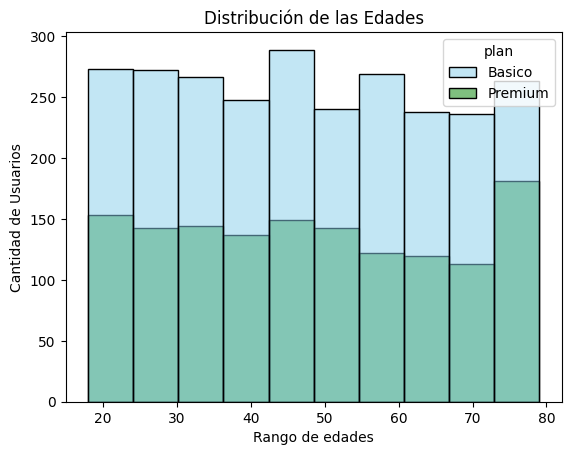

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', bins=10,
             hue='plan', palette=['skyblue','green'])
plt.xlabel('Rango de edades')
plt.ylabel('Cantidad de Usuarios')
plt.title('Distribución de las Edades')
plt.show()

💡Insights:
- La distribución es relativamente simétrica y uniforme across todos
  los rangos de edad, sin una concentración clara en ningún grupo etario.
- La proporción entre plan Básico y Premium se mantiene relativamente
  estable (~60/40) en la mayoría de los rangos de edad.
- Excepción notable: en usuarios mayores de 70 años el plan Premium
  representa una proporción significativamente mayor, sugiriendo que
  los usuarios de mayor edad tienden a preferir el plan Premium.
- No existe un patrón claro de edad que defina la preferencia de plan
  en la mayoría de los rangos.

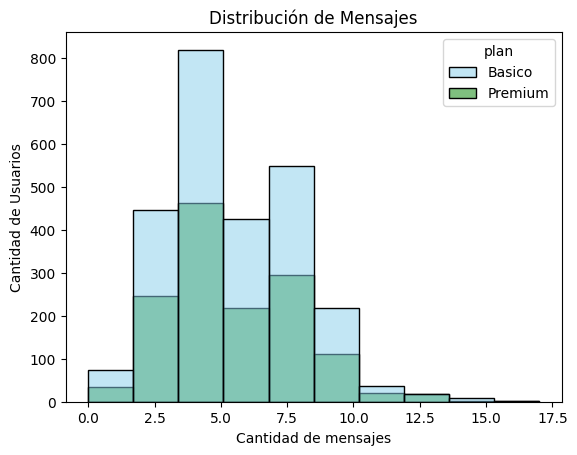

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', bins=10,
             hue='plan', palette=['skyblue','green'])
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de Usuarios')
plt.title('Distribución de Mensajes')
plt.show()

💡Insights:

- La distribución es bimodal con dos picos: el principal entre 3-5 mensajes
  y un segundo pico entre 7-8 mensajes, sugiriendo dos grupos de usuarios
  con comportamientos de mensajería distintos.
- La distribución está sesgada a la derecha con pocos usuarios enviando
  más de 10 mensajes.
- La proporción Básico/Premium (~60/40) se mantiene consistente en todos
  los rangos de mensajes, sin que el plan defina el comportamiento de mensajería.

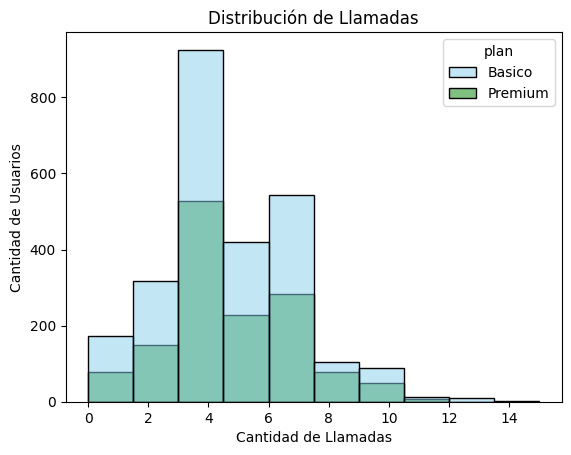

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', bins=10,
             hue='plan', palette=['skyblue','green'])
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.title('Distribución de Llamadas')
plt.show()

💡Insights:

- La distribución es bimodal con dos picos: el principal entre 3-4 llamadas
  y un segundo pico entre 6-7, similar al patrón de mensajes.
- La distribución está sesgada a la derecha con muy pocos usuarios
  realizando más de 10 llamadas.
- La proporción Básico/Premium se mantiene estable (~65/35) en la mayoría
  de los rangos, sin embargo en usuarios con más de 7 llamadas la proporción
  de Premium aumenta, sugiriendo que los usuarios con mayor volumen de
  llamadas tienden a preferir el plan Premium.

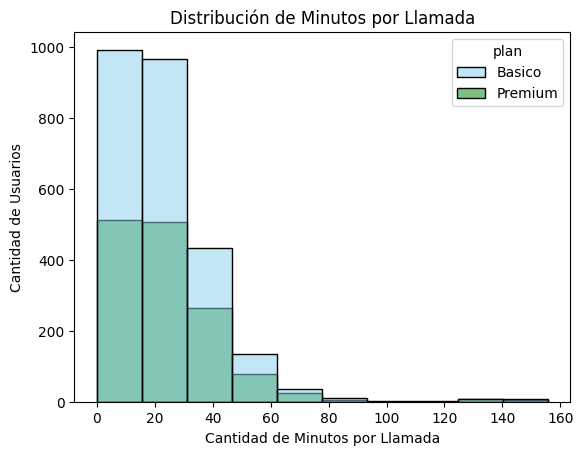

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', bins=10,
             hue='plan', palette=['skyblue','green'])
plt.xlabel('Cantidad de Minutos por Llamada')
plt.ylabel('Cantidad de Usuarios')
plt.title('Distribución de Minutos por Llamada')
plt.show()

💡Insights:

- La distribución está fuertemente sesgada a la derecha (right skewed),
  con la mayoría de usuarios concentrados entre 0-30 minutos totales
  de llamadas.
- A diferencia de mensajes y llamadas, esta distribución es unimodal
  con un solo pico claro al inicio.
- La proporción Básico/Premium se mantiene consistente (~60/40) en todos
  los rangos, sin que el plan influya en el volumen de minutos consumidos.
- Se confirman outliers por encima de 120 minutos, consistente con lo
  detectado en el análisis estadístico inicial, que deberán considerarse
  al momento de modelar o segmentar usuarios.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

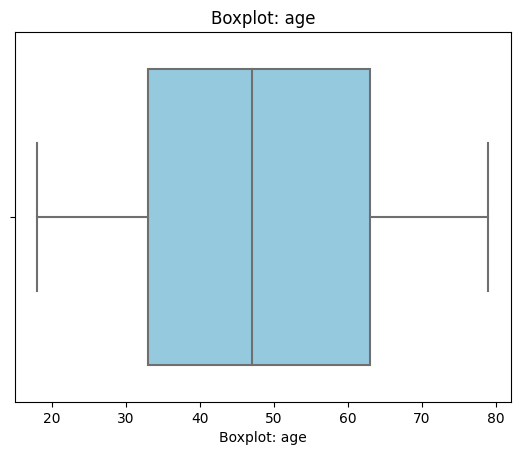

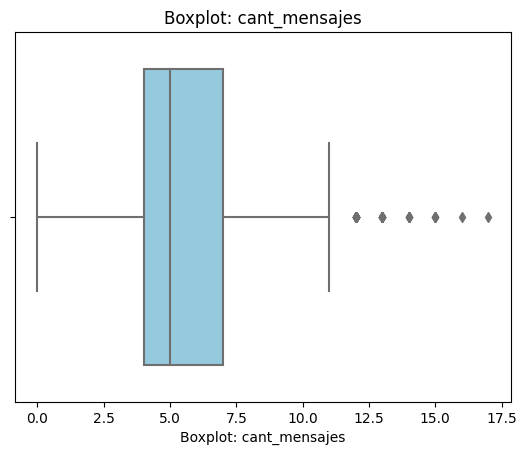

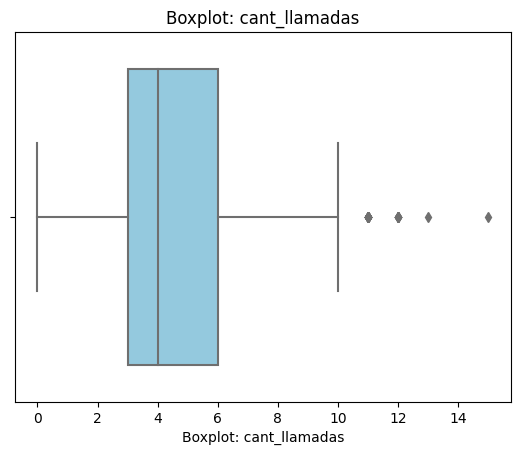

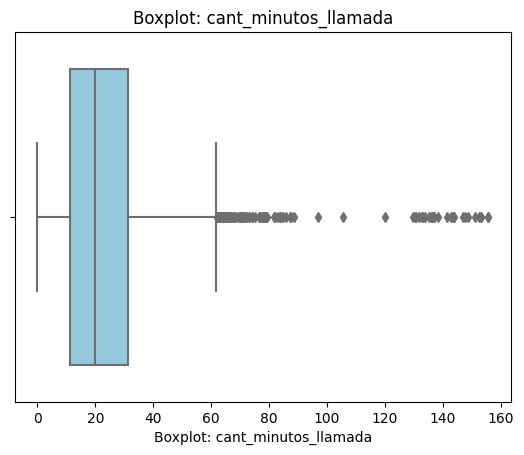

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
        sns.boxplot(data=user_profile, x=col, color='skyblue')
        plt.xlabel(f'Boxplot: {col}')
        plt.title(f'Boxplot: {col}')
        plt.show()

💡Insights:
- `age`: distribución simétrica sin outliers, con la mayoría de usuarios
  entre 32 y 62 años y mediana cercana a 47.
- `cant_mensajes`: sesgada a la derecha con outliers entre 12-17 mensajes,
  concentración principal entre 4-7 mensajes con mediana en ~5.
- `cant_llamadas`: sesgada a la derecha con pocos outliers entre 11-15
  llamadas, concentración principal entre 3-6 llamadas con mediana en ~4.
- - `cant_minutos_llamada`: fuertemente sesgada a la derecha con una gran
  cantidad de outliers — dos grupos visibles: uno entre 65-105 minutos
  y otro entre 130-160 minutos. La concentración principal está entre
  10-30 minutos con mediana cercana a 20. Es la columna con mayor
  presencia de outliers de todas las analizadas.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    Limite_superior = Q3 + 1.5 * IQR
    print(f'--- {col} ---\nQ1: {Q1}\nQ3: {Q3}\nIQR: {IQR}\nLimite Superior: {Limite_superior}\n')


--- cant_mensajes ---
Q1: 4.0
Q3: 7.0
IQR: 3.0
Limite Superior: 11.5

--- cant_llamadas ---
Q1: 3.0
Q3: 6.0
IQR: 3.0
Limite Superior: 10.5

--- cant_minutos_llamada ---
Q1: 11.12
Q3: 31.415
IQR: 20.295
Limite Superior: 61.8575



In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:

- `cant_mensajes`: el límite superior IQR es 11.5 pero el máximo es 17.0.
  Se aplica capping en 11.5 porque enviar más de 11 mensajes es
  estadísticamente atípico y podría distorsionar promedios y segmentaciones,
  sin embargo los valores no son imposibles desde el punto de vista del negocio.

- `cant_llamadas`: el límite superior IQR es 10.5 pero el máximo es 15.0.
  Se aplica capping en 10.5 porque realizar más de 10 llamadas en el período
  analizado representa un comportamiento fuera de lo normal para la mayoría
  de usuarios, y mantenerlos inflaría el promedio de uso.

- `cant_minutos_llamada`: el límite superior es 61.8 pero el máximo llega
  a 155.7 — más del doble del límite. Se aplica capping en 61.8 porque
  estos valores extremos son los que más distorsionan el análisis dado el
  gran volumen de outliers detectados en el boxplot, y podrían sesgar
  cualquier segmentación o modelo posterior.

**Decisión general:** se prefiere capping sobre eliminación porque estos
usuarios siguen siendo clientes reales y válidos — simplemente se modera
su valor extremo para que no distorsionen el análisis sin perder su registro.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
def client_segment(row):
    mensajes = row['cant_mensajes']
    llamadas = row['cant_llamadas']

    if llamadas < 5 and mensajes < 5:
            return 'Bajo uso'
    elif llamadas < 10 and mensajes < 10:
            return 'Uso medio'
    else:
        return'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(client_segment, axis = 1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def client_age(row):
    age = row['age']


    if age < 30:
        return 'Joven'
    elif age < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(client_age, axis = 1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

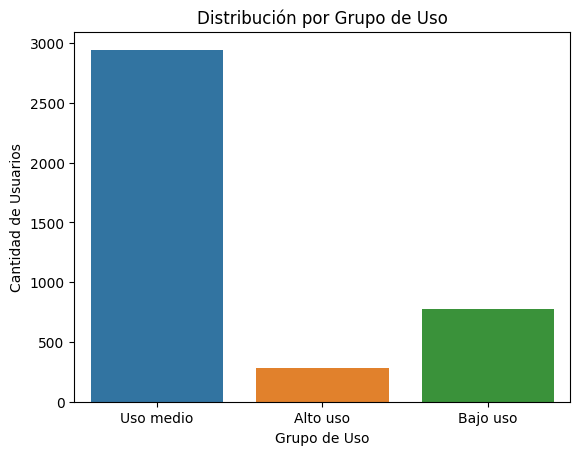

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.title('Distribución por Grupo de Uso')
plt.show()

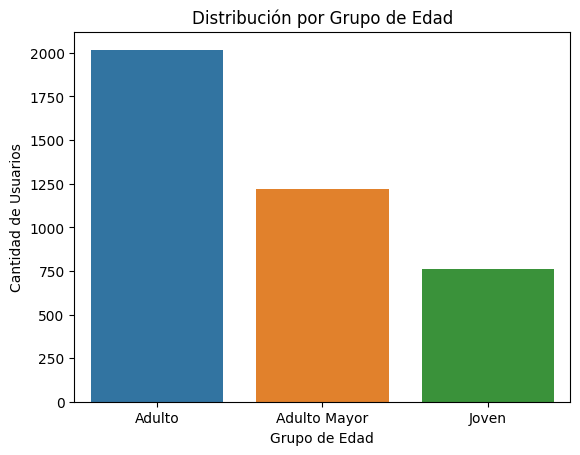

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.title('Distribución por Grupo de Edad')
plt.show()

In [ ]:
pd.crosstab(user_profile['grupo_edad'], user_profile['grupo_uso'])

grupo_uso,Alto uso,Bajo uso,Uso medio
grupo_edad,,,
Adulto,154,364,1500
Adulto Mayor,74,257,891
Joven,51,157,552



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmente los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

## 14.1. Análisis Ejecutivo

⚠️ **Problemas detectados en los datos**

- `age`: contenía sentinel values (-999) que distorsionaban la distribución — se reemplazaron por la mediana.
- `city`: 469 valores nulos (11.7%) y valores "?" — se marcaron como nulos.
- `churn_date`: 3,534 nulos (88.4%) — interpretados como clientes activos, no como datos faltantes.
- `reg_date`: 40 fechas futuras (año 2026, 1%) fuera del rango de análisis — se marcaron como nulos.
- `duration` y `length`: nulos estructurales dependientes del tipo de registro — confirmados como MAR y se dejaron como nulos.
- `cant_mensajes`, `cant_llamadas` y `cant_minutos_llamada`: outliers con distribución sesgada a la derecha — se recomienda aplicar capping en 11.5, 10.5 y 61.8 respectivamente.

🔍 **Segmentos por Edad**

- El grupo más grande es **Adulto** con aproximadamente 2,000 usuarios, seguido de **Adulto Mayor** con 1,230 y **Joven** con 760.
- Se observa una tendencia en usuarios Adultos Mayores hacia el plan Premium, siendo el único grupo donde la proporción Premium supera el promedio general.

📊 **Segmentos por Nivel de Uso**

- El **Uso medio** domina en todos los grupos de edad: Adulto (1,500), Adulto Mayor (891) y Joven (552).
- El **Alto uso** es el segmento más pequeño (~300 usuarios) pero representa un grupo con potencial de upgrade a plan Premium.

➡️ Esto sugiere que la base de clientes de ConnectaTel está concentrada en usuarios adultos con uso moderado, con una minoría de heavy users que podría estar siendo subatendida por los planes actuales.

💡 **Recomendaciones**

- Desarrollar un plan de retención enfocado en el segmento **Adulto con Uso medio** (1,500 usuarios) por ser el grupo de mayor volumen y mayor impacto en el negocio.
- Ofrecer promociones de upgrade al plan **Premium dirigidas al grupo de Alto uso** con plan Básico. *(Se sugiere como análisis adicional cruzar `grupo_uso` con `plan` para validar esta hipótesis.)*
- Diseñar campañas específicas para **Adultos Mayores** aprovechando su mayor afinidad hacia el plan Premium.
- Como análisis futuro, cruzar `grupo_uso` con `plan` para identificar con precisión qué segmentos tienen mayor potencial de upgrade.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`